In [1]:
import numpy as np
import matplotlib.pyplot as plt
months = np.arange(1, 60.1, 0.1) # 月为单位，覆盖五年
temperature_effect = np.sin((months - 3) * np.pi / 6)  # 假设最热在7月，每12个月重复一次
precipitation_effect = np.cos((months - 9) * np.pi / 6)  # 假设降水高峰在9月，每12个月重复一次
daylight_effect = np.sin((months - 6) * np.pi / 6)  # 日照时长变化，假设最长在6月，每12个月重复一次
random_fluctuations = 0.2 * np.random.randn(len(months))  # 添加随机波动
extreme_weather_events = np.zeros(len(months))
for year in range(1):
    # 在每年中随机选择某些月份作为极端天气事件的发生点
    extreme_months = np.random.randint(1, 13, 3) + year * 12
    for month in extreme_months:
        idx = np.where(np.abs(months - month) < 0.5)[0]
        if len(idx) > 0:
            extreme_weather_events[idx] += 0.5
def gaussian(x, mu, sigma):
    return np.exp(-0.5 * ((np.mod(x - 1, 12) + 1 - mu) / sigma) ** 2)
agriculture_activities = np.zeros(len(months))
for year in range(5):
    agriculture_activities += gaussian(np.mod(months - 1, 12) + 1, 4, 0.5) + gaussian(np.mod(months - 1, 12) + 1, 9, 0.5)
    
total_effect = (temperature_effect + precipitation_effect + daylight_effect +
                agriculture_activities + random_fluctuations + extreme_weather_events)

    
min_value = np.min(total_effect)
if min_value < 0.2:
    total_effect -= (min_value - 0.2)
total_effect = (total_effect - np.min(total_effect)) / (np.max(total_effect) - np.min(total_effect))
total_effect = 0.2 + (total_effect - np.min(total_effect)) * (1 - 0.2)


In [2]:
'''
confidence_interval = 0.05
plt.figure(figsize=(7,2))
from IPython.display import set_matplotlib_formats
set_matplotlib_formats('svg')
plt.plot(months, total_effect, linewidth=2, color='blue',label='Species Richness')
plt.fill_between(months, total_effect-confidence_interval, total_effect+confidence_interval,color='blue',alpha=0.2,label='confidence interval')
plt.grid(True)
plt.legend()
plt.ylabel('Species Richness (%)')
plt.xlabel('months')
'''

"\nconfidence_interval = 0.05\nplt.figure(figsize=(7,2))\nfrom IPython.display import set_matplotlib_formats\nset_matplotlib_formats('svg')\nplt.plot(months, total_effect, linewidth=2, color='blue',label='Species Richness')\nplt.fill_between(months, total_effect-confidence_interval, total_effect+confidence_interval,color='blue',alpha=0.2,label='confidence interval')\nplt.grid(True)\nplt.legend()\nplt.ylabel('Species Richness (%)')\nplt.xlabel('months')\n"

In [3]:
'''

def f(x):
    return (-0.01462044487*x**2+59.17365663*x-59845.89449)

f_values = (f(months/12+2020))/100

confidence_interval = 0.05
plt.figure(figsize=(12.5,3))
from IPython.display import set_matplotlib_formats
set_matplotlib_formats('svg')
plt.plot(months, total_effect, linewidth=2, color='blue',label='Net Species Richness')
plt.fill_between(months, total_effect-confidence_interval, total_effect+confidence_interval,color='blue',alpha=0.2,label='confidence interval')
plt.plot(months, f_values,color='purple',linewidth=2,label='Loss of Species Richness')
plt.fill_between(months, f_values-0.07, f_values+0.07,color='purple',alpha=0.2)
plt.plot(months, total_effect-f_values, linewidth=2,color='red',label='Total Species Richness')
plt.fill_between(months,total_effect-f_values-0.05, total_effect-f_values+0.05, color='red',alpha=0.2 )
plt.grid(True)
plt.legend()
plt.ylabel('Normalized Ratio (%)')
plt.xticks(np.arange(1,73,12),['2020', '2021', '2022', '2023' ,'2024','2025'])
plt.xlabel('years')
'''

"\n\ndef f(x):\n    return (-0.01462044487*x**2+59.17365663*x-59845.89449)\n\nf_values = (f(months/12+2020))/100\n\nconfidence_interval = 0.05\nplt.figure(figsize=(12.5,3))\nfrom IPython.display import set_matplotlib_formats\nset_matplotlib_formats('svg')\nplt.plot(months, total_effect, linewidth=2, color='blue',label='Net Species Richness')\nplt.fill_between(months, total_effect-confidence_interval, total_effect+confidence_interval,color='blue',alpha=0.2,label='confidence interval')\nplt.plot(months, f_values,color='purple',linewidth=2,label='Loss of Species Richness')\nplt.fill_between(months, f_values-0.07, f_values+0.07,color='purple',alpha=0.2)\nplt.plot(months, total_effect-f_values, linewidth=2,color='red',label='Total Species Richness')\nplt.fill_between(months,total_effect-f_values-0.05, total_effect-f_values+0.05, color='red',alpha=0.2 )\nplt.grid(True)\nplt.legend()\nplt.ylabel('Normalized Ratio (%)')\nplt.xticks(np.arange(1,73,12),['2020', '2021', '2022', '2023' ,'2024','20

In [4]:
months_2 = np.arange(1, 60.1, 0.1)  # 使用更精细的时间步长以获得平滑曲线，覆盖5年

# 模拟环境因素影响（温度、降水、日照时长）
temperatureEffect_2 = np.sin((months_2 - 3) * np.pi / 6)  # 假设最热在7月，每12个月重复一次
precipitationEffect_2 = np.cos((months_2 - 9) * np.pi / 6)  # 假设降水高峰在9月，每12个月重复一次
daylightEffect_2 = np.sin((months_2 - 6) * np.pi / 6)  # 日照时长变化，假设最长在6月，每12个月重复一次

# 引入额外影响因素（例如病虫害爆发、极端天气等）
randomFluctuations_2 = 0.07 * np.random.randn(len(months_2))  # 添加随机波动
extremeWeatherEvents_2 = np.zeros(len(months_2))

# 农业活动因子：播种期和收获期（使用高斯分布来模拟这些活动的影响）
def gaussian(x, mu, sigma):
    return np.exp(-0.4 * ((np.mod(x-1, 12)+1 - mu) / sigma)**2)

agricultureActivities_2 = np.zeros(len(months_2))
for year_2 in range(5):
    agricultureActivities_2 += gaussian(np.mod(months_2-1, 12)+1, 4, 0.5) + gaussian(np.mod(months_2-1, 12)+1, 9, 0.5)

# 生物多样性因子：以给定函数随时间逐渐增加
L = 1  # 最大值
k = 0.05  # 增长率
t0 = 30  # 中心点
alpha = 0.5  # 正弦波幅度
omega = 2 * np.pi / 12  # 正弦波周期（每年一个周期）

biodiversityIncrease = L / (1 + np.exp(-k * (months - t0))) * (1 + alpha * np.sin(omega * months))

# 综合所有影响因素
totalEffect_2 = temperatureEffect_2 + precipitationEffect_2 + daylightEffect_2 + agricultureActivities_2 + randomFluctuations_2 + extremeWeatherEvents_2 + biodiversityIncrease

# 确保最小值为0.3，并正则化数据以便于比较
minValue = np.min(totalEffect_2)
if minValue < 0.3:
    totalEffect_2 = totalEffect_2 - (minValue - 0.3)
totalEffect_2 = (totalEffect_2 - np.min(totalEffect_2)) / (np.max(totalEffect_2) - np.min(totalEffect_2))

# 设置最小值为0.3
totalEffect_2 = 0.3 + (totalEffect_2 - np.min(totalEffect_2)) * (1 - 0.3)

In [5]:
def f_1(x):
    return (-0.01462044487*x**2+59.17365663*x-59845.89449)

def f_2(x):
    return (-0.01462044487*x**2+59.17365663*x-59860.89449)    

In [6]:
f1_values = (f_1(months/12+2020))/100
f2_values=  (f_2(months/12+2020))/100

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_54636\843324947.py:2: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats('svg')


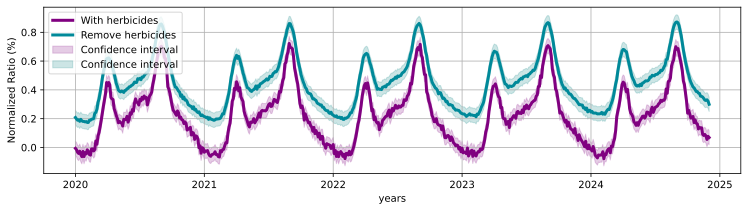

In [7]:
from IPython.display import set_matplotlib_formats
set_matplotlib_formats('svg')

plt.figure(figsize=(12.5,3))
plt.plot(months, total_effect-f1_values,linewidth=3,color='purple',label='With herbicides')
plt.plot(months_2, totalEffect_2-f2_values,linewidth=3,color='#008999',label='Remove herbicides')

plt.fill_between(months,  total_effect-f1_values-0.05, total_effect-f1_values+0.05,color='purple',label='Confidence interval',alpha=0.2)
plt.fill_between(months_2,  totalEffect_2-f2_values-0.05, totalEffect_2-f2_values+0.05,color='#008080',label='Confidence interval',alpha=0.2)

plt.xticks(np.arange(1, 73, 12), ['2020', '2021', '2022', '2023', '2024','2025'])
plt.grid(True)
plt.ylabel('Normalized Ratio (%)')
plt.xlabel('years')
plt.legend()

